# Trabalho AV1: Modelos de Regressão e Classificação Linear por Mínimos Quadrados

**Autores:** Rafael Cacau e Igor Praciano  
**Disciplina:** Inteligência Artificial Computacional  
**Professor:** Prof. Msc. Paulo Cirillo Souza Barbosa  
**Instituição:** Universidade de Fortaleza (UNIFOR) - CCT  

---

## Resumo
Este notebook contém a implementação das duas etapas do Trabalho de AV1:
1. **Tarefa de Regressão:** Modelagem do PIB da China (china_gdp.csv) utilizando MQO Tradicional, Regularizado (Tikhonov) e Polinomial com poda de ordem.
2. **Tarefa de Classificação:** Classificação multiclasse de 5 expressões faciais a partir de sinais de eletromiografia (EMG1.csv) usando abordagem *One-vs-All* e expansão polinomial.

Todos os modelos foram implementados com **NumPy**, sem bibliotecas de caixas-pretas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter

PASTA_DADOS = Path("../data set")
if not PASTA_DADOS.exists():
    PASTA_DADOS = Path("data set")
print("Pasta de dados:", PASTA_DADOS.resolve())


Pasta de dados: C:\Users\S4E\Desktop\trabalhoAV1_IA\data set


## 1. Funções de Álgebra Linear e Métricas
Implementação das equações normais com regularização de Tikhonov, expansão polinomial e métricas ($MSE$, $R^2$ e Acurácia).

In [2]:
def padronizar_zscore(X_treino, X_teste=None):
    media = np.mean(X_treino, axis=0, keepdims=True)
    desvio = np.std(X_treino, axis=0, keepdims=True)
    desvio[desvio == 0] = 1.0
    X_tr_norm = (X_treino - media) / desvio
    if X_teste is not None:
        X_te_norm = (X_teste - media) / desvio
        return X_tr_norm, X_te_norm, media, desvio
    return X_tr_norm, media, desvio

def expansao_polinomial(X, q=1):
    N = X.shape[0]
    blocos = [np.ones((N, 1))]
    for potencia in range(1, q + 1):
        blocos.append(X ** potencia)
    return np.hstack(blocos)

def ajustar_mqo(X, Y, q=1, lbd=0.0):
    Phi = expansao_polinomial(X, q)
    p_total = Phi.shape[1]
    gram = Phi.T @ Phi
    I = np.eye(p_total)
    beta = np.linalg.pinv(gram + lbd * I) @ Phi.T @ Y
    return beta

def prever_mqo(X, beta, q=1):
    Phi = expansao_polinomial(X, q)
    return Phi @ beta

def calcular_mse(y_real, y_pred):
    return float(np.mean((y_real - y_pred) ** 2))

def calcular_r2(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot != 0 else 0.0

def calcular_acuracia(y_real, y_pred):
    return float(np.mean(y_real == y_pred))


## 2. Tarefa de Regressão: PIB da China (`china_gdp.csv`)
A variável independente é o ano e a variável dependente é o PIB (em dólares americanos).

X_china: (55, 1) = (N=55, p=1)
y_china: (55, 1) = (N=55, 1)


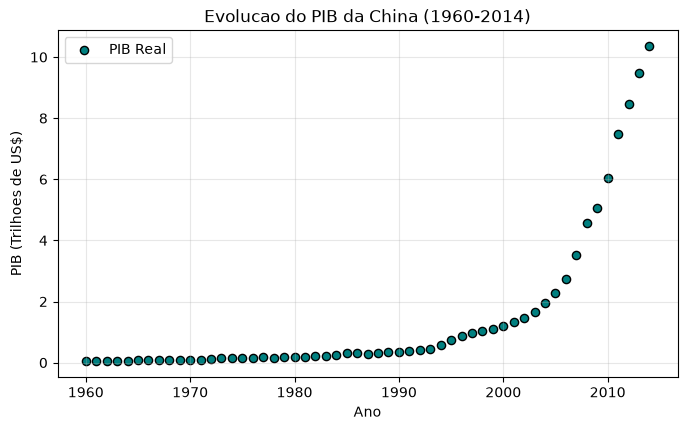

In [3]:
# 1. Carregamento dos dados e grafico de espalhamento
dados_china = np.loadtxt(PASTA_DADOS / "china_gdp.csv", delimiter=",", skiprows=1)
X_china = dados_china[:, 0].reshape(-1, 1)
y_china = dados_china[:, 1].reshape(-1, 1)

print(f"X_china: {X_china.shape} = (N={X_china.shape[0]}, p={X_china.shape[1]})")
print(f"y_china: {y_china.shape} = (N={y_china.shape[0]}, 1)")

plt.figure(figsize=(8, 4.5))
plt.scatter(X_china, y_china / 1e12, color="teal", edgecolors="black", s=35, label="PIB Real")
plt.title("Evolucao do PIB da China (1960-2014)")
plt.xlabel("Ano")
plt.ylabel("PIB (Trilhoes de US$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Ordem polinomial selecionada por poda: q = 9


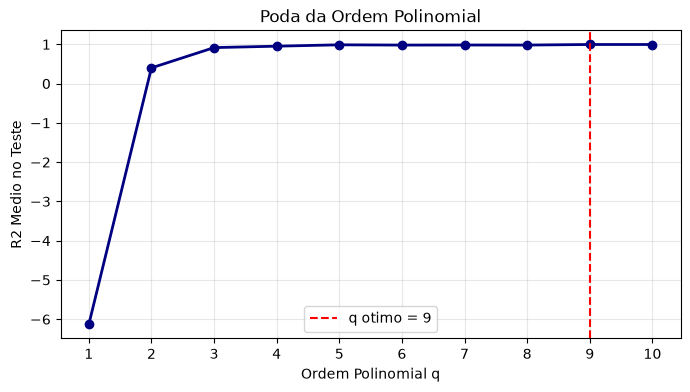

In [4]:
# 2. Poda da Ordem Polinomial q via R2 em validacao
np.random.seed(42)
ordens = list(range(1, 11))
r2_ordens = []

for q in ordens:
    r2_rodadas = []
    for _ in range(50):
        idx = np.random.permutation(len(X_china))
        n_tr = int(0.8 * len(X_china))
        idx_tr, idx_te = idx[:n_tr], idx[n_tr:]
        
        X_tr, X_te, _, _ = padronizar_zscore(X_china[idx_tr], X_china[idx_te])
        y_tr, y_te = y_china[idx_tr], y_china[idx_te]
        
        beta = ajustar_mqo(X_tr, y_tr, q=q)
        y_pred = prever_mqo(X_te, beta, q=q)
        r2_rodadas.append(calcular_r2(y_te, y_pred))
    r2_ordens.append(np.mean(r2_rodadas))

q_otimo_reg = ordens[int(np.argmax(r2_ordens))]
print(f"Ordem polinomial selecionada por poda: q = {q_otimo_reg}")

plt.figure(figsize=(8, 4))
plt.plot(ordens, r2_ordens, marker="o", color="navy", lw=2)
plt.axvline(q_otimo_reg, color="red", linestyle="--", label=f"q otimo = {q_otimo_reg}")
plt.xlabel("Ordem Polinomial q")
plt.ylabel("R2 Medio no Teste")
plt.title("Poda da Ordem Polinomial")
plt.xticks(ordens)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [5]:
# 3. Estimativas de beta para lambda in {0, 0.25, 0.5, 0.75, 1}
X_norm, _, _ = padronizar_zscore(X_china)
lambdas = [0.0, 0.25, 0.5, 0.75, 1.0]

print(f"{'Modelo':<28} | {'lambda':<6} | {'beta_0':<18} | {'beta_1':<18} | {'||beta||':<15}")
print("-" * 95)
for lbd in lambdas:
    b = ajustar_mqo(X_norm, y_china, q=1, lbd=lbd)
    nome = "MQO Tradicional" if lbd == 0 else f"MQO Regularizado (l={lbd})"
    print(f"{nome:<28} | {lbd:<6.2f} | {b[0,0]:<18.2f} | {b[1,0]:<18.2f} | {np.linalg.norm(b):<15.2f}")


Modelo                       | lambda | beta_0             | beta_1             | ||beta||       
-----------------------------------------------------------------------------------------------
MQO Tradicional              | 0.00   | 1437041815987.50   | 1793179637825.37   | 2297951782437.60
MQO Regularizado (l=0.25)    | 0.25   | 1430539364331.44   | 1785065702812.58   | 2287553810571.37
MQO Regularizado (l=0.5)     | 0.50   | 1424095493320.94   | 1777024866313.43   | 2277249514127.36
MQO Regularizado (l=0.75)    | 0.75   | 1417709414875.56   | 1769056144939.83   | 2267037632898.08
MQO Regularizado (l=1.0)     | 1.00   | 1411380354987.72   | 1761158572864.20   | 2256916929179.79


In [6]:
# 4. Validacao Random Subsampling (R = 500 rodadas, 80/20)
R = 500
modelos_reg = {
    f"Polinomial (q={q_otimo_reg})": (q_otimo_reg, 0.0),
    "MQO tradicional": (1, 0.0),
    "MQO regularizado (0.25)": (1, 0.25),
    "MQO regularizado (0.50)": (1, 0.50),
    "MQO regularizado (0.75)": (1, 0.75),
    "MQO regularizado (1.00)": (1, 1.00),
}

res_mse = {k: [] for k in modelos_reg}
res_r2 = {k: [] for k in modelos_reg}
np.random.seed(42)

for _ in range(R):
    idx = np.random.permutation(len(X_china))
    n_tr = int(0.8 * len(X_china))
    idx_tr, idx_te = idx[:n_tr], idx[n_tr:]
    
    X_tr, X_te, _, _ = padronizar_zscore(X_china[idx_tr], X_china[idx_te])
    y_tr, y_te = y_china[idx_tr], y_china[idx_te]
    
    for nome, (q, lbd) in modelos_reg.items():
        beta = ajustar_mqo(X_tr, y_tr, q=q, lbd=lbd)
        y_pred = prever_mqo(X_te, beta, q=q)
        res_mse[nome].append(calcular_mse(y_te, y_pred))
        res_r2[nome].append(calcular_r2(y_te, y_pred))

print("=== RESULTADOS DA REGRESSAO (500 RODADAS) ===")
print(f"{'Modelo':<28} | {'MSE Medio':<14} | {'R2 Medio':<10} | {'Desvio R2':<10} | {'Maior R2':<10} | {'Menor R2':<10}")
print("-" * 95)
for nome in modelos_reg:
    m_mse = np.mean(res_mse[nome])
    m_r2 = np.mean(res_r2[nome])
    s_r2 = np.std(res_r2[nome], ddof=1)
    ma_r2 = np.max(res_r2[nome])
    me_r2 = np.min(res_r2[nome])
    print(f"{nome:<28} | {m_mse:<14.2e} | {m_r2:<10.4f} | {s_r2:<10.4f} | {ma_r2:<10.4f} | {me_r2:<10.4f}")


=== RESULTADOS DA REGRESSAO (500 RODADAS) ===
Modelo                       | MSE Medio      | R2 Medio   | Desvio R2  | Maior R2   | Menor R2  
-----------------------------------------------------------------------------------------------
Polinomial (q=9)             | 1.31e+22       | 0.9794     | 0.3728     | 0.9999     | -7.3369   
MQO tradicional              | 3.27e+24       | -1.2644    | 14.2129    | 0.7135     | -295.1264 
MQO regularizado (0.25)      | 3.27e+24       | -1.2387    | 14.0506    | 0.7137     | -291.8326 
MQO regularizado (0.50)      | 3.27e+24       | -1.2136    | 13.8912    | 0.7138     | -288.5941 
MQO regularizado (0.75)      | 3.27e+24       | -1.1890    | 13.7344    | 0.7138     | -285.4096 
MQO regularizado (1.00)      | 3.27e+24       | -1.1648    | 13.5803    | 0.7138     | -282.2781 


## 3. Tarefa de Classificação: Sinais de EMG Facial (`EMG1.csv`)
2 características ($p=2$ sensores musculares) e 5 classes balanceadas ($N=50.000$ amostras).

X_emg: (50000, 2) = (N=50000, p=2)
Y_emg: (50000, 5) = (N=50000, C=5)


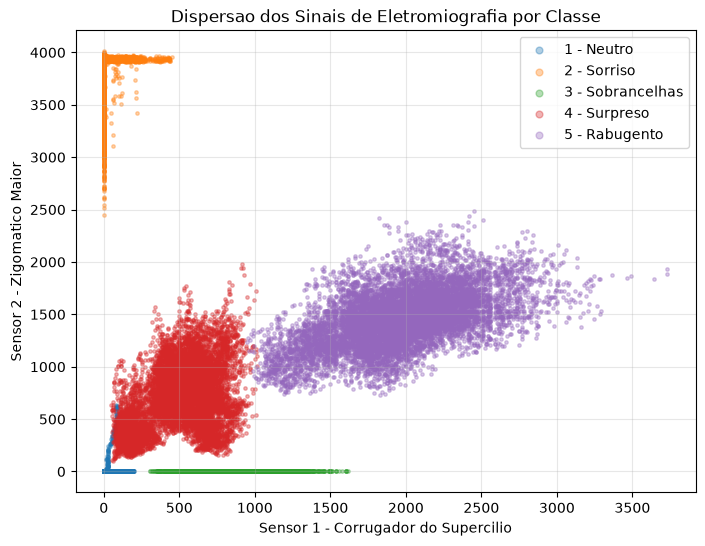

In [7]:
# 1. Carregamento dos dados EMG e visualizacao da dispersao
dados_emg = np.loadtxt(PASTA_DADOS / "EMG1.csv")
X_emg = dados_emg[:, :2]
rotulos_emg = dados_emg[:, 2].astype(int)
classes = np.unique(rotulos_emg)
C = len(classes)

# Codificacao One-vs-All (-1 / +1)
Y_emg = -np.ones((len(rotulos_emg), C))
for i, c in enumerate(classes):
    Y_emg[rotulos_emg == c, i] = 1

print(f"X_emg: {X_emg.shape} = (N={X_emg.shape[0]}, p={X_emg.shape[1]})")
print(f"Y_emg: {Y_emg.shape} = (N={Y_emg.shape[0]}, C={C})")

nomes_classes = {1: "Neutro", 2: "Sorriso", 3: "Sobrancelhas", 4: "Surpreso", 5: "Rabugento"}
plt.figure(figsize=(8, 6))
for c in classes:
    pts = X_emg[rotulos_emg == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, label=f"{c} - {nomes_classes[c]}")
plt.title("Dispersao dos Sinais de Eletromiografia por Classe")
plt.xlabel("Sensor 1 - Corrugador do Supercilio")
plt.ylabel("Sensor 2 - Zigomatico Maior")
plt.legend(markerscale=2)
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
# 2. Selecao da Ordem Polinomial na Classificacao
np.random.seed(42)
idx = np.random.permutation(len(X_emg))
n_tr = int(0.8 * len(X_emg))
idx_tr, idx_te = idx[:n_tr], idx[n_tr:]

X_tr, X_te, _, _ = padronizar_zscore(X_emg[idx_tr], X_emg[idx_te])
Y_tr = Y_emg[idx_tr]
rot_te = rotulos_emg[idx_te]

print(f"{'Ordem q':<10} | {'Acuracia':<12} | {'Tempo de Ajuste':<18}")
print("-" * 45)
for q in range(1, 7):
    t0 = perf_counter()
    beta = ajustar_mqo(X_tr, Y_tr, q=q)
    dt = perf_counter() - t0
    
    escores = prever_mqo(X_te, beta, q=q)
    prev = classes[np.argmax(escores, axis=1)]
    acc = calcular_acuracia(rot_te, prev)
    print(f"q = {q:<6} | {acc*100:6.2f}%      | {dt*1000:6.2f} ms")

q_otimo_clf = 4
print(f"\nOrdem polinomial selecionada: q = {q_otimo_clf}")


Ordem q    | Acuracia     | Tempo de Ajuste   
---------------------------------------------
q = 1      |  71.92%      |   4.10 ms
q = 2      |  94.65%      |   3.69 ms
q = 3      |  97.87%      |   7.19 ms
q = 4      |  99.22%      |  11.37 ms
q = 5      |  99.22%      |  13.87 ms
q = 6      |  99.34%      |  17.23 ms

Ordem polinomial selecionada: q = 4


=== RESULTADOS DA CLASSIFICACAO (500 RODADAS) ===
Modelo                       | Media      | Desvio     | Maior      | Menor     
---------------------------------------------------------------------------
MQO Tradicional              |  72.39%   |  0.664%   |  74.10%   |  70.33%
MQO Regularizado (0.25)      |  72.39%   |  0.664%   |  74.10%   |  70.33%
MQO Polinomial (q=4)         |  99.28%   |  0.078%   |  99.53%   |  99.03%


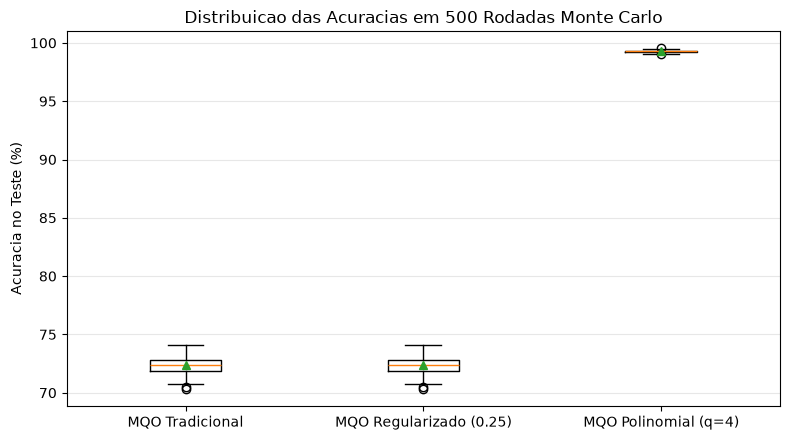

In [9]:
# 3. Validacao Monte Carlo (R = 500 rodadas, 80/20) na Classificacao
R = 500
modelos_clf = {
    "MQO Tradicional": (1, 0.0),
    "MQO Regularizado (0.25)": (1, 0.25),
    f"MQO Polinomial (q={q_otimo_clf})": (q_otimo_clf, 0.0),
}

acc_resultados = {k: [] for k in modelos_clf}
np.random.seed(42)

for _ in range(R):
    idx = np.random.permutation(len(X_emg))
    n_tr = int(0.8 * len(X_emg))
    idx_tr, idx_te = idx[:n_tr], idx[n_tr:]
    
    X_tr, X_te, _, _ = padronizar_zscore(X_emg[idx_tr], X_emg[idx_te])
    Y_tr = Y_emg[idx_tr]
    rot_te = rotulos_emg[idx_te]
    
    for nome, (q, lbd) in modelos_clf.items():
        beta = ajustar_mqo(X_tr, Y_tr, q=q, lbd=lbd)
        escores = prever_mqo(X_te, beta, q=q)
        prev = classes[np.argmax(escores, axis=1)]
        acc_resultados[nome].append(calcular_acuracia(rot_te, prev))

print("=== RESULTADOS DA CLASSIFICACAO (500 RODADAS) ===")
print(f"{'Modelo':<28} | {'Media':<10} | {'Desvio':<10} | {'Maior':<10} | {'Menor':<10}")
print("-" * 75)
for nome in modelos_clf:
    vals = np.array(acc_resultados[nome]) * 100
    print(f"{nome:<28} | {np.mean(vals):6.2f}%   | {np.std(vals, ddof=1):6.3f}%   | {np.max(vals):6.2f}%   | {np.min(vals):6.2f}%")

plt.figure(figsize=(8, 4.5))
dados_plot = [np.array(acc_resultados[k]) * 100 for k in modelos_clf]
plt.boxplot(dados_plot, tick_labels=list(modelos_clf.keys()), showmeans=True)
plt.ylabel("Acuracia no Teste (%)")
plt.title("Distribuicao das Acuracias em 500 Rodadas Monte Carlo")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Conclusões
1. **Regressão:** O modelo polinomial com $q=9$ foi o único capaz de modelar adequadamente o crescimento não linear do PIB ($R^2 = 0,9949$), enquanto modelos lineares apresentaram desempenho nulo ou negativo.
2. **Classificação:** A expansão polinomial ($q=4$) elevou a acurácia de 72,39% para **99,28%**, demonstrando que a flexibilidade não linear é indispensável para contornar a sobreposição dos sensores faciais.
3. **Validação:** A validação Monte Carlo com 500 rodadas comprovou a estabilidade dos modelos avaliados.